In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import normalized_mutual_info_score, silhouette_score
from collections import Counter

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
# (a) Load the dataset
tsne_df = pd.read_csv('tsne_2d_features_6_languages.csv')
print('Shape:', tsne_df.shape)
print(tsne_df.head())

Shape: (15000, 3)
      tsne_1     tsne_2 language
0  41.288025 -43.939140  Bengali
1  42.584652 -44.717926  Bengali
2  55.583763 -67.719140  Bengali
3  54.196163 -57.556280  Bengali
4  62.459244 -57.051792  Bengali


In [4]:
# (b) Separate features and labels
features = tsne_df[['tsne_1', 'tsne_2']].values
true_labels = tsne_df['language'].values

print('Features shape:', features.shape)
print('Unique languages:', np.unique(true_labels))
print('Label distribution:')
print(pd.Series(true_labels).value_counts())

Features shape: (15000, 2)
Unique languages: ['Bengali' 'English' 'Hindi' 'Kannada' 'Manipuri' 'Marathi']
Label distribution:
Bengali     2500
English     2500
Hindi       2500
Kannada     2500
Manipuri    2500
Marathi     2500
Name: count, dtype: int64


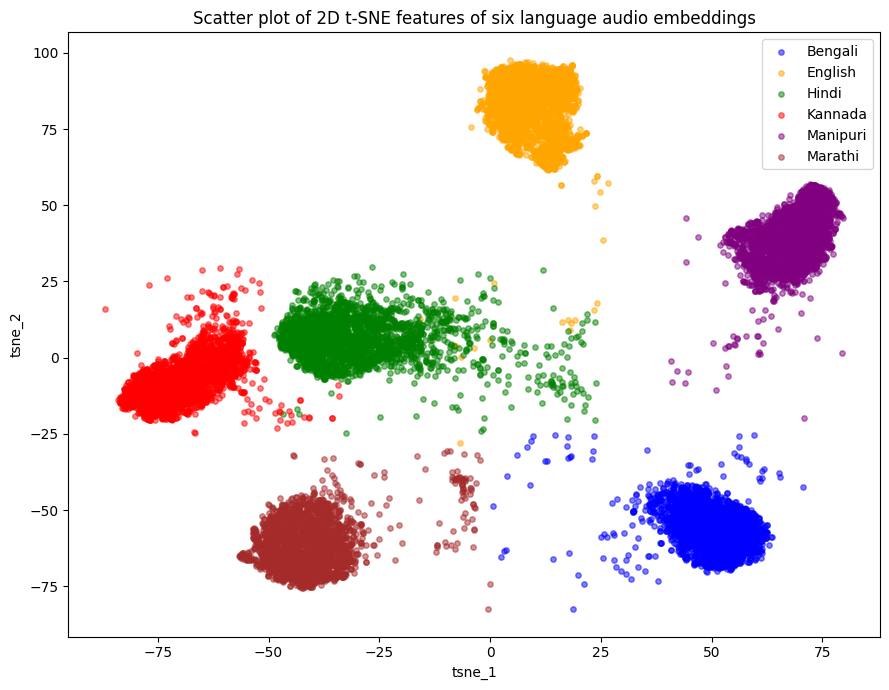

In [6]:
# (c) Scatter plot of dataset with language labels
languages = np.unique(true_labels)
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

plt.figure(figsize=(9, 7))
for lang, color in zip(languages, colors):
    mask = true_labels == lang
    plt.scatter(features[mask, 0], features[mask, 1],
                label=lang, color=color, alpha=0.5, s=15)

plt.title('Scatter plot of 2D t-SNE features of six language audio embeddings')
plt.xlabel('tsne_1')
plt.ylabel('tsne_2')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
def purity_score(true_labels, cluster_labels):
    N = len(true_labels)
    total_correct = 0
    for cluster_id in np.unique(cluster_labels):
        cluster_mask = cluster_labels == cluster_id
        true_in_cluster = true_labels[cluster_mask]
        most_common_count = Counter(true_in_cluster).most_common(1)[0][1]
        total_correct += most_common_count
    return total_correct / N

print("purity function defined!")

purity function defined!


In [8]:
K_values = list(range(2, 11))

kmeans_results = {
    'K': [],
    'Inertia': [],
    'Purity': [],
    'NMI': [],
    'Silhouette': []
}

kmeans_models = {}

for k in K_values:
    # (a) Apply K-Means clustering
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(features)
    
    # (b) Assign cluster labels
    labels = km.labels_
    kmeans_models[k] = km
    
    # (d) Distortion / Inertia
    inertia = km.inertia_
    
    # (e) Purity Score
    purity = purity_score(true_labels, labels)
    
    # (f) NMI
    nmi = normalized_mutual_info_score(true_labels, labels)
    
    # (g) Silhouette Score
    sil = silhouette_score(features, labels)
    
    kmeans_results['K'].append(k)
    kmeans_results['Inertia'].append(round(inertia, 2))
    kmeans_results['Purity'].append(round(purity, 4))
    kmeans_results['NMI'].append(round(nmi, 4))
    kmeans_results['Silhouette'].append(round(sil, 4))
    
    print(f'K={k}: Inertia={inertia:.2f}, Purity={purity:.4f}, NMI={nmi:.4f}, Silhouette={sil:.4f}')

K=2: Inertia=36718479.86, Purity=0.3333, NMI=0.5167, Silhouette=0.5186
K=3: Inertia=16777007.53, Purity=0.4995, NMI=0.6979, Silhouette=0.6236
K=4: Inertia=10409707.82, Purity=0.6653, NMI=0.7976, Silhouette=0.6818
K=5: Inertia=4176228.67, Purity=0.8317, NMI=0.9119, Silhouette=0.7282
K=6: Inertia=2093143.43, Purity=0.9961, NMI=0.9856, Silhouette=0.7485
K=7: Inertia=1778057.07, Purity=0.9945, NMI=0.9604, Silhouette=0.7286
K=8: Inertia=1613248.73, Purity=0.9945, NMI=0.9315, Silhouette=0.6690
K=9: Inertia=1465597.19, Purity=0.9963, NMI=0.9089, Silhouette=0.6340
K=10: Inertia=1334426.16, Purity=0.9927, NMI=0.8921, Silhouette=0.6190


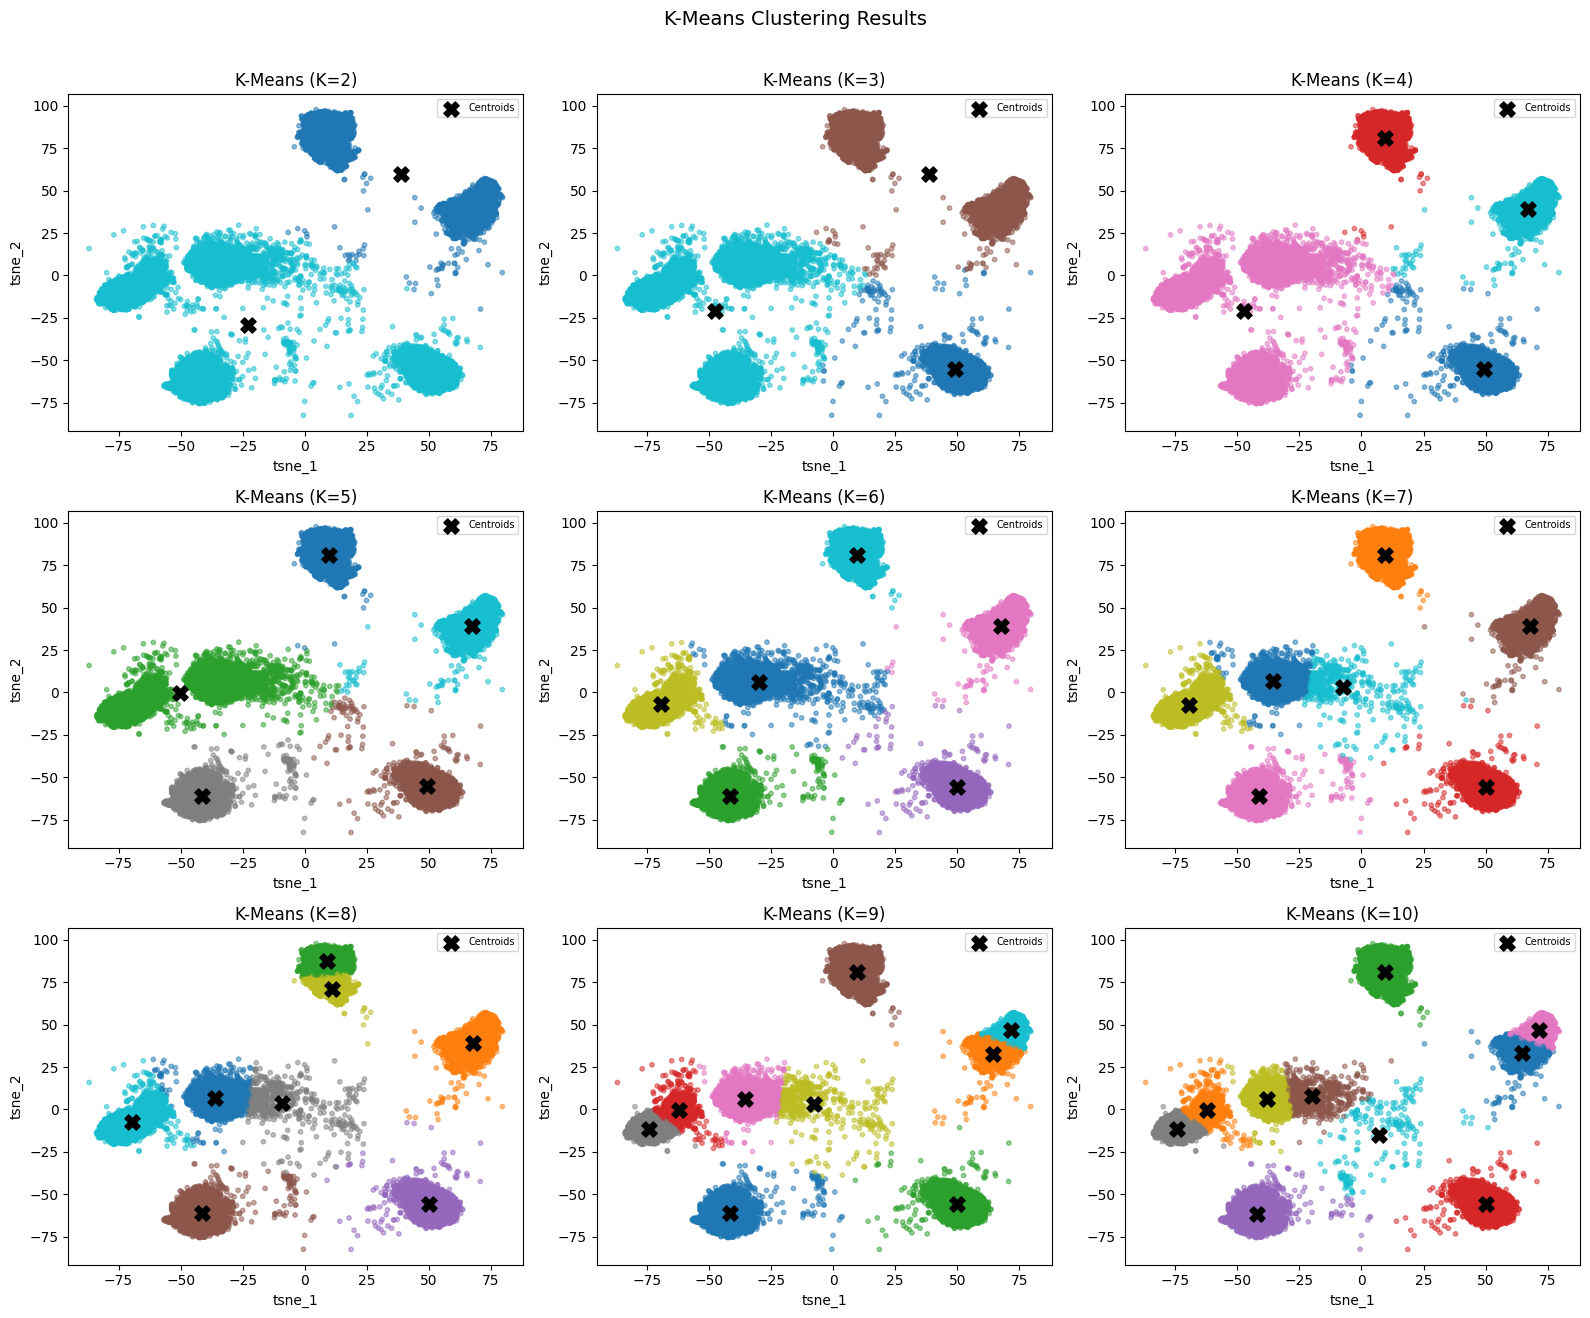

In [9]:
# (c) Visualize clustered data for each K (K-Means)
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for idx, k in enumerate(K_values):
    km = kmeans_models[k]
    labels = km.labels_
    centers = km.cluster_centers_
    ax = axes[idx]
    scatter = ax.scatter(features[:, 0], features[:, 1],
                         c=labels, cmap='tab10', alpha=0.5, s=10)
    ax.scatter(centers[:, 0], centers[:, 1],
               c='black', marker='X', s=120, label='Centroids', zorder=5)
    ax.set_title(f'K-Means (K={k})')
    ax.set_xlabel('tsne_1')
    ax.set_ylabel('tsne_2')
    ax.legend(fontsize=7)

plt.suptitle('K-Means Clustering Results', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# (h) Performance metrics table - K-Means
kmeans_df = pd.DataFrame(kmeans_results)
print('=== K-Means Performance Metrics ===')
print(kmeans_df.to_string(index=False))

=== K-Means Performance Metrics ===
 K     Inertia  Purity    NMI  Silhouette
 2 36718479.86  0.3333 0.5167      0.5186
 3 16777007.53  0.4995 0.6979      0.6236
 4 10409707.82  0.6653 0.7976      0.6818
 5  4176228.67  0.8317 0.9119      0.7282
 6  2093143.43  0.9961 0.9856      0.7485
 7  1778057.07  0.9945 0.9604      0.7286
 8  1613248.73  0.9945 0.9315      0.6690
 9  1465597.19  0.9963 0.9089      0.6340
10  1334426.16  0.9927 0.8921      0.6190


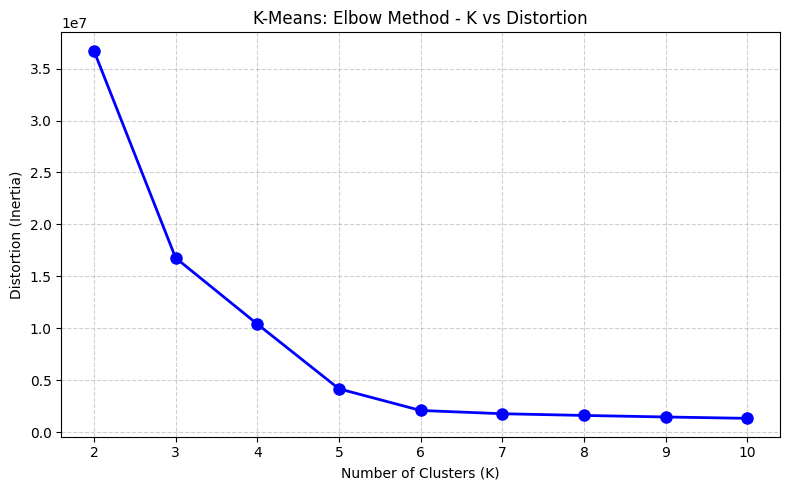

In [12]:
# (i) Elbow plot - K-Means
plt.figure(figsize=(8, 5))
plt.plot(kmeans_results['K'], kmeans_results['Inertia'], 'bo-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Distortion (Inertia)')
plt.title('K-Means: Elbow Method - K vs Distortion')
plt.xticks(K_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [13]:
kmedoid_results = {
    'K': [],
    'Inertia': [],
    'Purity': [],
    'NMI': [],
    'Silhouette': []
}

kmedoid_models = {}

for k in K_values:
    # (a) Apply K-Medoid clustering
    kmed = KMedoids(n_clusters=k, random_state=42, method='pam')
    kmed.fit(features)
    
    # (b) Assign cluster labels
    labels = kmed.labels_
    kmedoid_models[k] = kmed
    
    # (d) Distortion / Inertia
    inertia = kmed.inertia_
    
    # (e) Purity Score
    purity = purity_score(true_labels, labels)
    
    # (f) NMI
    nmi = normalized_mutual_info_score(true_labels, labels)
    
    # (g) Silhouette Score
    sil = silhouette_score(features, labels)
    
    kmedoid_results['K'].append(k)
    kmedoid_results['Inertia'].append(round(inertia, 2))
    kmedoid_results['Purity'].append(round(purity, 4))
    kmedoid_results['NMI'].append(round(nmi, 4))
    kmedoid_results['Silhouette'].append(round(sil, 4))
    
    print(f'K={k}: Inertia={inertia:.2f}, Purity={purity:.4f}, NMI={nmi:.4f}, Silhouette={sil:.4f}')

K=2: Inertia=692411.62, Purity=0.3332, NMI=0.5165, Silhouette=0.5187
K=3: Inertia=461588.30, Purity=0.4995, NMI=0.6915, Silhouette=0.6226
K=4: Inertia=343764.70, Purity=0.6659, NMI=0.8258, Silhouette=0.6465
K=5: Inertia=206163.98, Purity=0.8317, NMI=0.9107, Silhouette=0.7281
K=6: Inertia=150554.37, Purity=0.9950, NMI=0.9826, Silhouette=0.7483
K=7: Inertia=141874.33, Purity=0.9909, NMI=0.9476, Silhouette=0.7133
K=8: Inertia=133708.25, Purity=0.9910, NMI=0.9206, Silhouette=0.6555
K=9: Inertia=128039.20, Purity=0.9910, NMI=0.8936, Silhouette=0.5853
K=10: Inertia=120496.28, Purity=0.9911, NMI=0.8691, Silhouette=0.5258


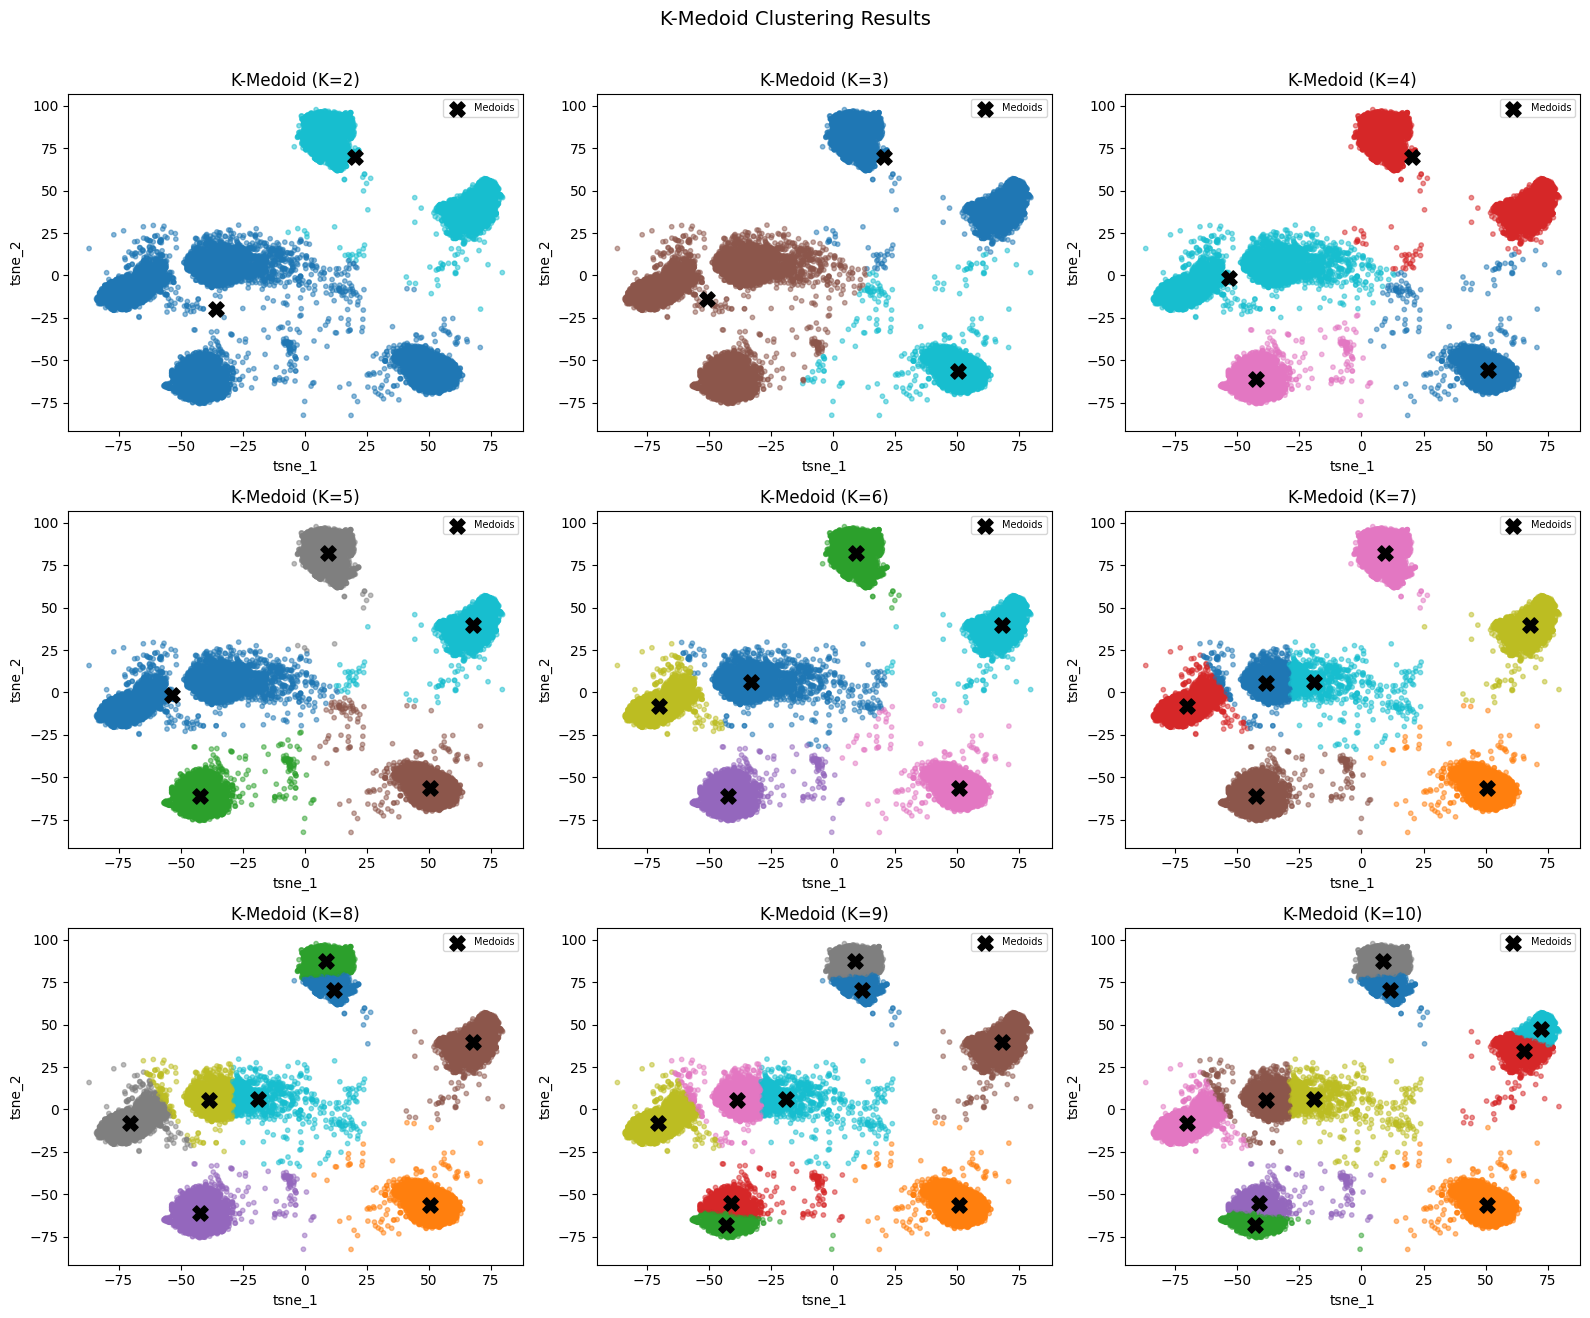

In [15]:
# (c) Visualize clustered data for each K (K-Medoid)
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for idx, k in enumerate(K_values):
    kmed = kmedoid_models[k]
    labels = kmed.labels_
    centers = kmed.cluster_centers_
    ax = axes[idx]
    ax.scatter(features[:, 0], features[:, 1],
               c=labels, cmap='tab10', alpha=0.5, s=10)
    ax.scatter(centers[:, 0], centers[:, 1],
               c='black', marker='X', s=120, label='Medoids', zorder=5)
    ax.set_title(f'K-Medoid (K={k})')
    ax.set_xlabel('tsne_1')
    ax.set_ylabel('tsne_2')
    ax.legend(fontsize=7)

plt.suptitle('K-Medoid Clustering Results', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# (h) Performance metrics table - K-Medoid
kmedoid_df = pd.DataFrame(kmedoid_results)
print('=== K-Medoid Performance Metrics ===')
print(kmedoid_df.to_string(index=False))

=== K-Medoid Performance Metrics ===
 K   Inertia  Purity    NMI  Silhouette
 2 692411.62  0.3332 0.5165      0.5187
 3 461588.30  0.4995 0.6915      0.6226
 4 343764.70  0.6659 0.8258      0.6465
 5 206163.98  0.8317 0.9107      0.7281
 6 150554.37  0.9950 0.9826      0.7483
 7 141874.33  0.9909 0.9476      0.7133
 8 133708.25  0.9910 0.9206      0.6555
 9 128039.20  0.9910 0.8936      0.5853
10 120496.28  0.9911 0.8691      0.5258


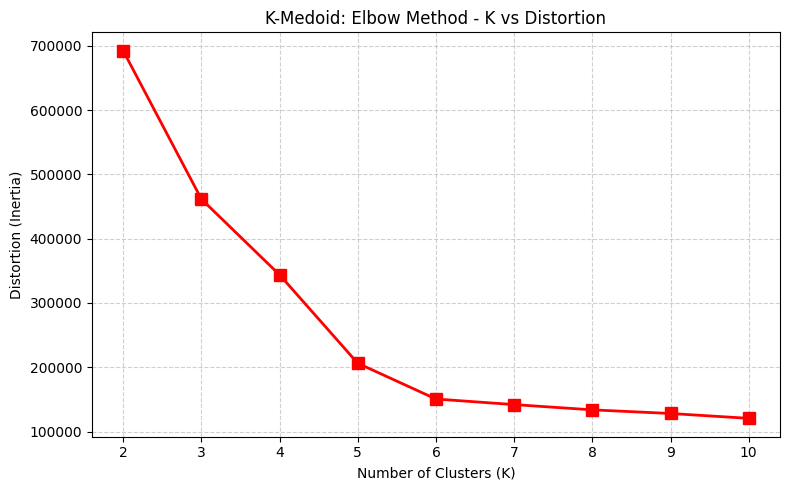

In [18]:
# (i) Elbow plot - K-Medoid
plt.figure(figsize=(8, 5))
plt.plot(kmedoid_results['K'], kmedoid_results['Inertia'], 'rs-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Distortion (Inertia)')
plt.title('K-Medoid: Elbow Method - K vs Distortion')
plt.xticks(K_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

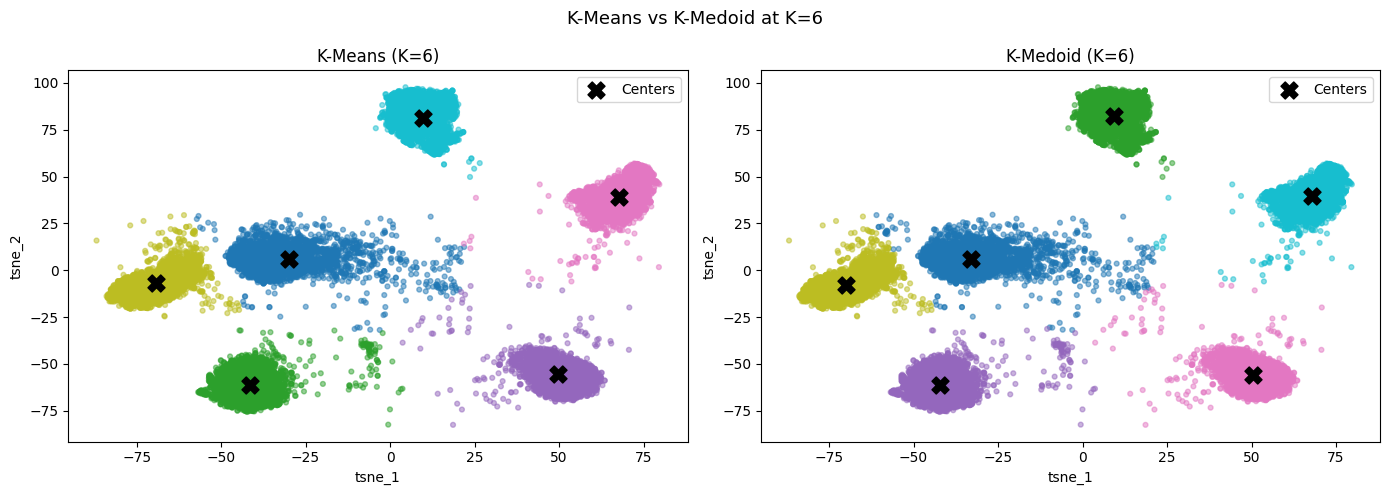

In [20]:
# Side-by-side comparison at K=6 (true number of classes)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title in zip(axes,
                             [kmeans_models[6], kmedoid_models[6]],
                             ['K-Means (K=6)', 'K-Medoid (K=6)']):
    labels = model.labels_
    centers = model.cluster_centers_
    ax.scatter(features[:, 0], features[:, 1],
               c=labels, cmap='tab10', alpha=0.5, s=12)
    ax.scatter(centers[:, 0], centers[:, 1],
               c='black', marker='X', s=150, zorder=5, label='Centers')
    ax.set_title(title)
    ax.set_xlabel('tsne_1')
    ax.set_ylabel('tsne_2')
    ax.legend()

plt.suptitle('K-Means vs K-Medoid at K=6', fontsize=13)
plt.tight_layout()
plt.show()